### Get Hourly BTC trading Data from Coinbase by using API


In [38]:
import requests
import pandas as pd
from datetime import datetime
def get_data():
    url = "https://api.exchange.coinbase.com/products/BTC-USD/candles"
    params = {
    "granularity": 3600,
    "start": "2026-01-01T00:00:00Z",
    "end": "2026-01-07T00:00:00Z" }
    response = requests.get(url, params=params)
    df = pd.DataFrame(response.json(), columns=[
    "time", "low", "high", "open", "close", "volume"
])
    df["time"] = pd.to_datetime(df["time"], unit='s')
    df.sort_values(by="time", inplace=True)
    return df
data = get_data()
print(data.head())



                   time       low      high      open     close      volume
144 2026-01-01 00:00:00  87456.10  87699.01  87497.95  87650.01  266.259951
143 2026-01-01 01:00:00  87642.20  87897.99  87650.00  87796.09  219.633717
142 2026-01-01 02:00:00  87666.89  87950.53  87796.09  87753.11  243.688205
141 2026-01-01 03:00:00  87667.26  87865.39  87754.42  87696.53  131.416104
140 2026-01-01 04:00:00  87361.74  87704.00  87696.53  87418.55  687.398560


### Generate trend buying and selling signal by using indicator of EMA_50 and EMA_200

In [21]:
def signal_generator(df):
    df["ema_50"] = df["close"].ewm(span=50, adjust=False).mean()
    df["ema_200"] = df["close"].ewm(span=200, adjust=False).mean()
    df["signal"] = 0
    df.loc[df["ema_50"] > df["ema_200"], "signal"] = 1
    df.loc[df["ema_50"] < df["ema_200"], "signal"] = -1
    return df
data = signal_generator(data)
print(data[[ "close", "ema_50", "ema_200", "signal"]].head())

                        close        ema_50       ema_200  signal
time                                                             
2026-01-01 00:00:00  87650.01  87650.010000  87650.010000       0
2026-01-01 01:00:00  87796.09  87655.738627  87651.463532       1
2026-01-01 02:00:00  87753.11  87659.557113  87652.474940       1
2026-01-01 03:00:00  87696.53  87661.007030  87652.913299       1
2026-01-01 04:00:00  87418.55  87651.498911  87650.581326       1


### Build Rebalance position each day through using volatility threshold


In [23]:
import numpy as np
def rebalance_position(df):
    df["log_returns"] = np.log(df["close"] / df["close"].shift(1))
    target_volatility = 0.0001
    #daily volatility estimation using rolling window 
    df["volatility"] = df["log_returns"].rolling(window=24).std()
    df["volatility"].fillna(method="bfill", inplace=True)
    
    #position sizing based on inverse volatility
    df["position_size"] = target_volatility / df["volatility"]
    df["weight_rebalanced"] = df.loc[df.index.hour == 0, "position_size"]
    df["weight_rebalanced"] = df["weight_rebalanced"].fillna(method="bfill")
    return df
data = rebalance_position(data)
print(data[[ "close",'log_returns', "volatility", "position_size"]])


                        close  log_returns  volatility  position_size
time                                                                 
2026-01-01 00:00:00  87650.01          NaN    0.001589       0.062939
2026-01-01 01:00:00  87796.09     0.001665    0.001589       0.062939
2026-01-01 02:00:00  87753.11    -0.000490    0.001589       0.062939
2026-01-01 03:00:00  87696.53    -0.000645    0.001589       0.062939
2026-01-01 04:00:00  87418.55    -0.003175    0.001589       0.062939
...                       ...          ...         ...            ...
2026-01-06 20:00:00  92447.52     0.004408    0.004015       0.024909
2026-01-06 21:00:00  93218.66     0.008307    0.004421       0.022618
2026-01-06 22:00:00  93323.07     0.001119    0.004425       0.022598
2026-01-06 23:00:00  93722.01     0.004266    0.004479       0.022328
2026-01-07 00:00:00  92652.02    -0.011482    0.005050       0.019803

[145 rows x 4 columns]


/var/folders/94/z2_z3thn10x6hzz91dytslr00000gn/T/ipykernel_49646/640778294.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["volatility"].fillna(method="bfill", inplace=True)
/var/folders/94/z2_z3thn10x6hzz91dytslr00000gn/T/ipykernel_49646/640778294.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["volatility"].fillna(method="bfill", inplace=True)
/var/folders/94/z2_z3thn10x6hzz91dytslr00000gn/T/ipykernel_49646/640778294.py:12:

### Calculate transaction cost when there is changing rebalnce position and changing trend signal 

In [ ]:
def transaction_costs(df):
    fee_rate = 0.001
    
    df["transaction_cost"] = 0.001 *(0.5*df["weight_rebalanced"].diff().abs()+0.5*df["signal"].diff().abs())
    df["transaction_cost"].fillna(0, inplace=True)
    return df
data = transaction_costs(data)
print(data[["close", "weight_rebalanced", "signal", "transaction_cost"]])

                        close  weight_rebalanced  signal  transaction_cost
time                                                                      
2026-01-01 00:00:00  87650.01           0.062939       0            0.0000
2026-01-01 01:00:00  87796.09           0.062939       1            0.0005
2026-01-01 02:00:00  87753.11           0.062939       1            0.0000
2026-01-01 03:00:00  87696.53           0.062939       1            0.0000
2026-01-01 04:00:00  87418.55           0.062939       1            0.0000
...                       ...                ...     ...               ...
2026-01-06 20:00:00  92447.52           0.019803       1            0.0000
2026-01-06 21:00:00  93218.66           0.019803       1            0.0000
2026-01-06 22:00:00  93323.07           0.019803       1            0.0000
2026-01-06 23:00:00  93722.01           0.019803       1            0.0000
2026-01-07 00:00:00  92652.02           0.019803       1            0.0000

[145 rows x 4 columns]


/var/folders/94/z2_z3thn10x6hzz91dytslr00000gn/T/ipykernel_49646/2557151591.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["transaction_cost"].fillna(0, inplace=True)


### calculate net return and equity curve


In [34]:
def calculate_returns(df):
    core_weight = 0.5
    vol_weight = 0.5
    conbined_weight = core_weight * df["signal"] + vol_weight * df["weight_rebalanced"]
    df["strategy_returns"] = conbined_weight * df["log_returns"]- df["transaction_cost"]
    df["equity_curve"] = np.exp(df["strategy_returns"]).cumsum()
    return df
data = calculate_returns(data)
print(data[["close", "signal", "weight_rebalanced", "strategy_returns", "equity_curve"]].tail())

                        close  signal  weight_rebalanced  strategy_returns  \
time                                                                         
2026-01-06 20:00:00  92447.52       1           0.019803          0.002248   
2026-01-06 21:00:00  93218.66       1           0.019803          0.004236   
2026-01-06 22:00:00  93323.07       1           0.019803          0.000571   
2026-01-06 23:00:00  93722.01       1           0.019803          0.002175   
2026-01-07 00:00:00  92652.02       1           0.019803         -0.005855   

                     equity_curve  
time                               
2026-01-06 20:00:00    140.022023  
2026-01-06 21:00:00    141.026267  
2026-01-06 22:00:00    142.026838  
2026-01-06 23:00:00    143.029016  
2026-01-07 00:00:00    144.023178  


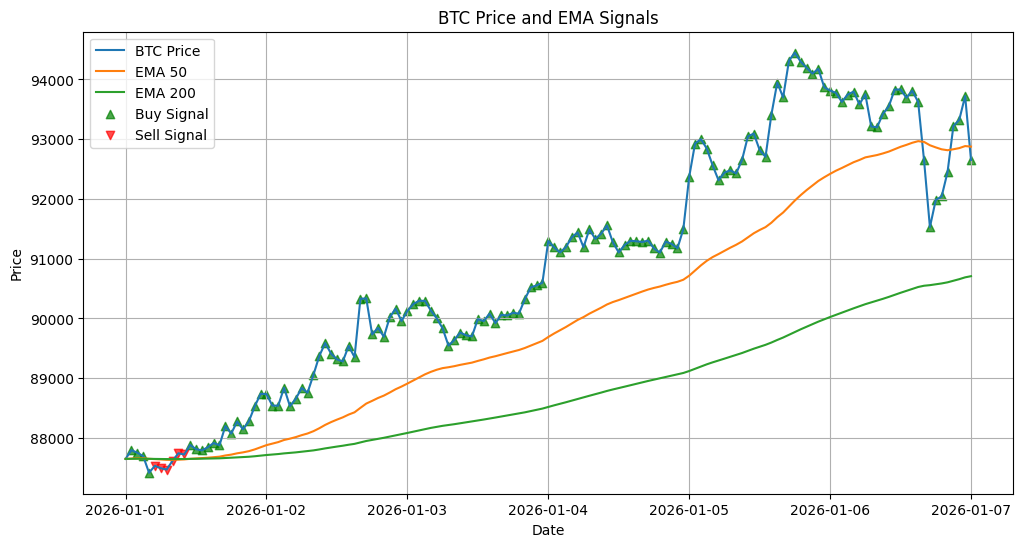

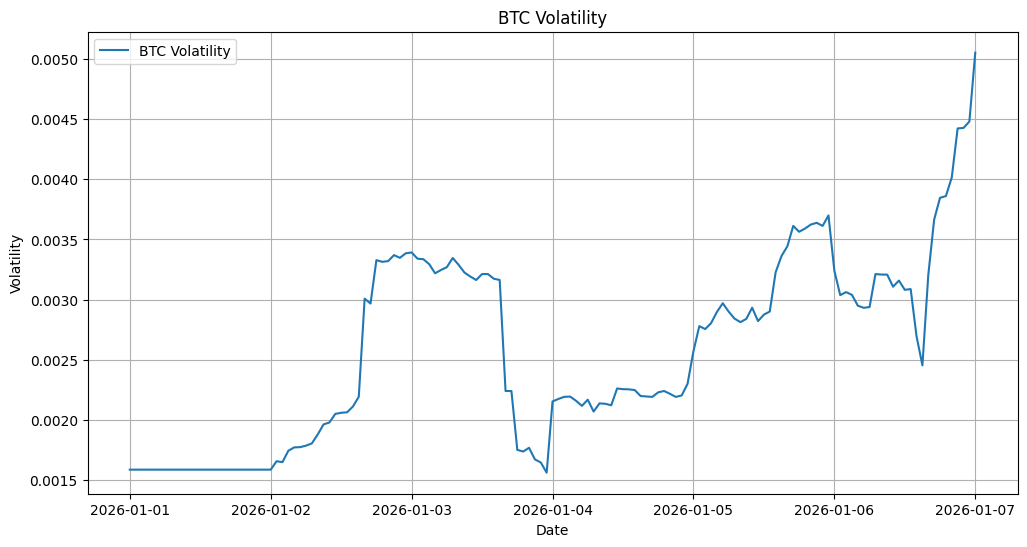

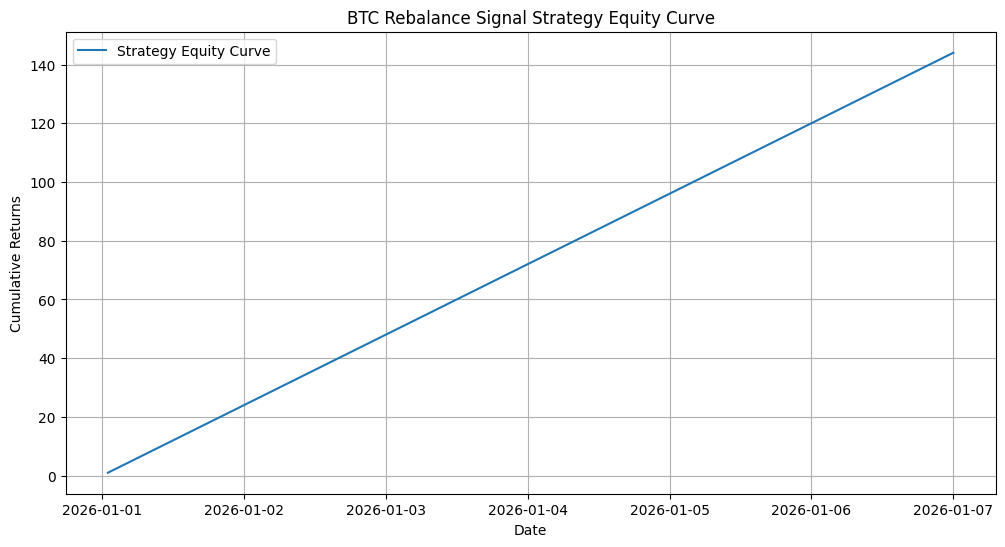

In [35]:
def plot(df):
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["close"], label="BTC Price")
    plt.plot(df.index, df["ema_50"], label="EMA 50")
    plt.plot(df.index, df["ema_200"], label="EMA 200")
    plt.scatter(df.index[df["signal"] == 1], df["close"][df["signal"] == 1], marker="^", color="green", label="Buy Signal", alpha=0.7)
    plt.scatter(df.index[df["signal"] == -1], df["close"][df["signal"] == -1], marker="v", color="red", label="Sell Signal", alpha=0.7)
    plt.title("BTC Price and EMA Signals")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["volatility"], label="BTC Volatility")
    plt.title("BTC Volatility")
    plt.xlabel("Date")
    plt.ylabel("Volatility")
    plt.legend()
    plt.grid()
    plt.show()


    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df["equity_curve"], label="Strategy Equity Curve")
    plt.title("BTC Rebalance Signal Strategy Equity Curve")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Returns")
    plt.legend()
    plt.grid()
    plt.show()
plot(data)